In [4]:
import pandas as pd
import glob

# Read the lookup table
index = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_20231117.csv")

# Define the function to split ALT and REF
def split_alt_ref(result_cell, out_folder):
    # Use glob to find the file matching the pattern
    file_pattern = f"enhancer_activities/MAD_OneTail_NoControl/*_MAD_{result_cell}.csv"
    file_list = glob.glob(file_pattern)
    
    # Make sure there is exactly one file matching the pattern
    if len(file_list) != 1:
        print(f"Error: Expected 1 file, found {len(file_list)} for {result_cell}")
        return
    
    # Read the matching file
    df = pd.read_csv(file_list[0], index_col=0)
    
    # Split the data into REF and ALT
    df_ref = pd.merge(index, df, left_on="1", right_index=True, how="inner").set_index("0").drop("1", axis=1).sort_index()
    df_alt = df.loc[df.index.isin(index["0"])]
    
    # Save the results to CSV files
    df_ref.to_csv(f"enhancer_activities/{out_folder}/20240912_MPRA3_MAD_mergedREF.csv")
    df_alt.to_csv(f"enhancer_activities/{out_folder}/20240912_MPRA3_MAD_mergedALT.csv")

# Call the function for each result_cell and output folder
split_alt_ref(result_cell="THP1_LPSIFNG", out_folder="THP1LPSIFNG_byAllele")
split_alt_ref(result_cell="THP1_IFNG", out_folder="THP1IFNG_byAllele")
split_alt_ref(result_cell="THP1_IFNB", out_folder="THP1IFNB_byAllele")
split_alt_ref(result_cell="THP1_Naive", out_folder="THP1Naive_byAllele")
split_alt_ref(result_cell="THP1Monocyte", out_folder="THP1Monocyte_byAllele")
split_alt_ref(result_cell="THP1Macrophage", out_folder="THP1Macrophage_byAllele")

split_alt_ref(result_cell="HMC3_LPSIFNG", out_folder="HMC3LPSIFNG_byAllele")
split_alt_ref(result_cell="HMC3_IFNG", out_folder="HMC3IFNG_byAllele")
split_alt_ref(result_cell="HMC3_IFNB", out_folder="HMC3IFNB_byAllele")
split_alt_ref(result_cell="HMC3_Naive", out_folder="HMC3Naive_byAllele")
split_alt_ref(result_cell="HMC3", out_folder="HMC3_byAllele")

split_alt_ref(result_cell="Striatum", out_folder="BrainStriatum_byAllele")
split_alt_ref(result_cell="Hippocampus", out_folder="BrainHippocampus_byAllele")
split_alt_ref(result_cell="Cortex", out_folder="BrainCortex_byAllele")
split_alt_ref(result_cell="Brain", out_folder="Brain_byAllele")

split_alt_ref(result_cell="HEK293T", out_folder="HEK293T_byAllele")


# Visualize the distribution of MAD score 

# One tail

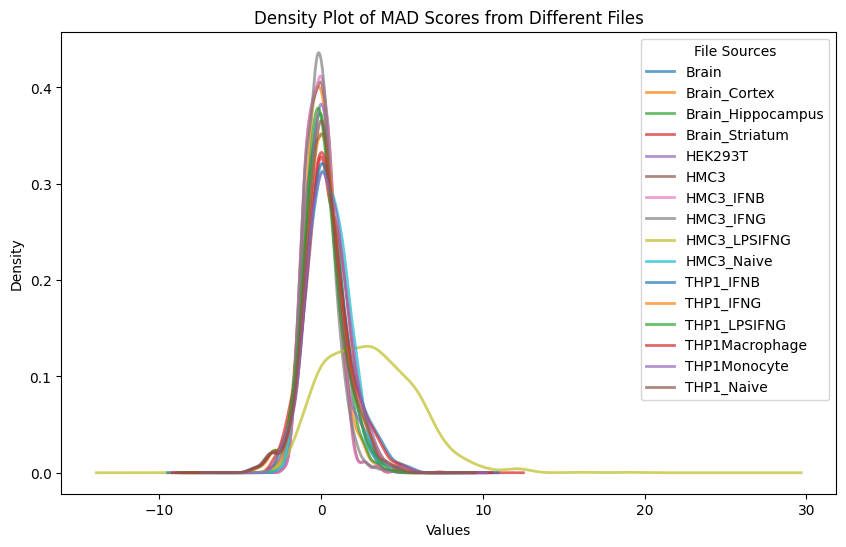

In [11]:
######################################################################################################################################
import pandas as pd
import glob

# Set the pattern to match files
pattern = '20240418_MAD_*.csv'
folder = 'enhancer_activities/MAD_OneTail_NoControl/'
# Get a list of all CSV files matching the pattern
file_list = glob.glob(folder+pattern)
dfs = []

# Read the 'mad.score' column from each file into a DataFrame and store them in a list
for file in file_list:
    df = pd.read_csv(file, index_col=0)[['mad.score']]
    df.rename(columns={'mad.score': f'{file.split("/")[-1][13:-4]}'}, inplace=True)  # Rename column to include file name
    dfs.append(df)

# Concatenate all the DataFrame columns into one
combined_df = pd.concat(dfs, axis=1)

import matplotlib.pyplot as plt

# Assuming 'combined_df' is your DataFrame with each column ready to be plotted
# Plotting the density plot for each column in the DataFrame
ax = combined_df.plot(kind='density', figsize=(10, 6), linewidth=2, alpha=0.7)

# Adding labels and title
ax.set_xlabel('Values')
ax.set_ylabel('Density')
ax.set_title('Density Plot of MAD Scores from Different Files')

# Displaying the legend
ax.legend(title='File Sources')

# Showing the plot
plt.show()


In [7]:
import pandas as pd
index= pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_20231117.csv")
def split_alt_ref(result_cell,out_folder):
    dir = f"enhancer_activities/MAD_TwoTail_NoControl/20240514_MAD_{result_cell}.csv"
    df = pd.read_csv(dir,index_col=0)
    df_ref = pd.merge(index,df,left_on = "1", right_index=True,how="inner").set_index("0").drop("1",axis=1).sort_index()
    df_alt = df.loc[df.index.isin(index["0"])]
    df_ref.to_csv(f"enhancer_activities/{out_folder}/20240514_MPRA3_MAD_mergedREF.csv")
    df_alt.to_csv(f"enhancer_activities/{out_folder}/20240514_MPRA3_MAD_mergedALT.csv")

split_alt_ref(result_cell="THP1_LPSIFNG",out_folder = "THP1LPSIFNG_byAllele")
split_alt_ref(result_cell="THP1_IFNG",out_folder = "THP1IFNG_byAllele")
split_alt_ref(result_cell="THP1_IFNB",out_folder = "THP1IFNB_byAllele")
split_alt_ref(result_cell="THP1_Naive",out_folder = "THP1Naive_byAllele")
split_alt_ref(result_cell="THP1Monocyte",out_folder = "THP1Monocyte_byAllele")
split_alt_ref(result_cell="THP1Macrophage",out_folder = "THP1Macrophage_byAllele")

split_alt_ref(result_cell="HMC3_LPSIFNG",out_folder = "HMC3LPSIFNG_byAllele")
split_alt_ref(result_cell="HMC3_IFNG",out_folder = "HMC3IFNG_byAllele")
split_alt_ref(result_cell="HMC3_IFNB",out_folder = "HMC3IFNB_byAllele")
split_alt_ref(result_cell="HMC3_Naive",out_folder = "HMC3Naive_byAllele")
split_alt_ref(result_cell="HMC3",out_folder = "HMC3_byAllele")

split_alt_ref(result_cell="Brain_Striatum",out_folder = "BrainStriatum_byAllele")
split_alt_ref(result_cell="Brain_Hippocampus",out_folder = "BrainHippocampus_byAllele")
split_alt_ref(result_cell="Brain_Cortex",out_folder = "BrainCortex_byAllele")

split_alt_ref(result_cell="HEK293T",out_folder = "HEK293T_byAllele")

# Two tail

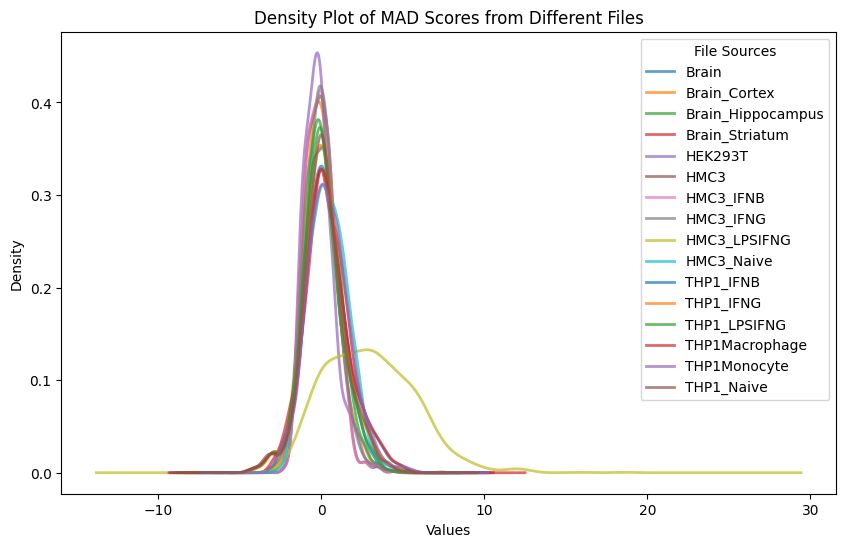

In [9]:

######################################################################################################################################
import pandas as pd
import glob

# Set the pattern to match files
pattern = '20240514_MAD_*.csv'
folder = 'enhancer_activities/MAD_TwoTail_NoControl/'
# Get a list of all CSV files matching the pattern
file_list = glob.glob(folder+pattern)
dfs = []

# Read the 'mad.score' column from each file into a DataFrame and store them in a list
for file in file_list:
    df = pd.read_csv(file, index_col=0)[['mad.score']]
    df.rename(columns={'mad.score': f'{file.split("/")[-1][13:-4]}'}, inplace=True)  # Rename column to include file name
    dfs.append(df)

# Concatenate all the DataFrame columns into one
combined_df = pd.concat(dfs, axis=1)

import matplotlib.pyplot as plt

# Assuming 'combined_df' is your DataFrame with each column ready to be plotted
# Plotting the density plot for each column in the DataFrame
ax = combined_df.plot(kind='density', figsize=(10, 6), linewidth=2, alpha=0.7)

# Adding labels and title
ax.set_xlabel('Values')
ax.set_ylabel('Density')
ax.set_title('Density Plot of MAD Scores from Different Files')

# Displaying the legend
ax.legend(title='File Sources')

# Showing the plot
plt.show()
